# Import Libraries

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers 

# Extract and Load Data

In [5]:
import zipfile
with zipfile.ZipFile("archive.zip","r") as zip_ref:
  zip_ref.extractall("/content/cat_dogs")

# Display Image

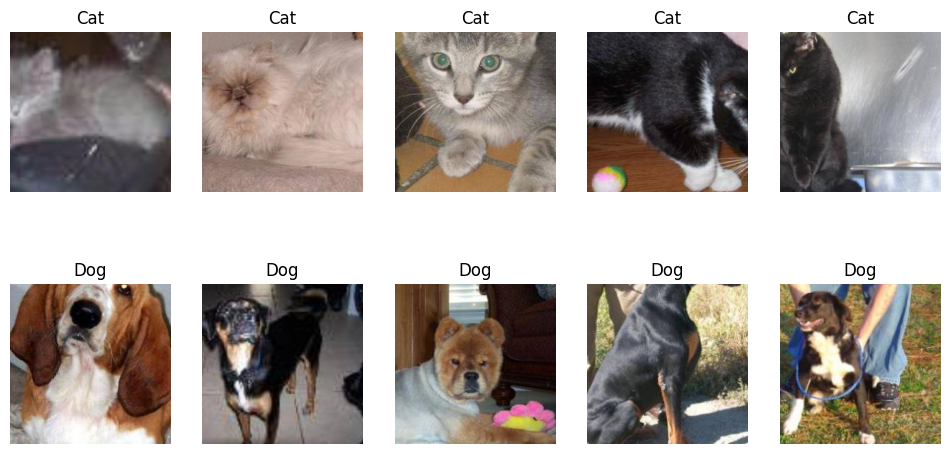

In [6]:
from PIL import Image
path = "/content/cat_dogs/train_transformed"
cat_images = [f for f in os.listdir(path) if f.startswith('cat')][:5]
dog_images = [f for f in os.listdir(path) if f.startswith("dog")][:5]
images = cat_images + dog_images
plt.figure(figsize=(12,6))
for i,file in enumerate(images):
  img = Image.open(os.path.join(path,file))
  plt.subplot(2,5,i+1)
  plt.imshow(img)
  plt.title("Cat" if file.startswith("cat") else "Dog")
  plt.axis('off');

In [7]:
files = os.listdir(path)
len(files)

2000

# Labels

In [8]:
labels = []
for file in files:
  if file.startswith("cat"):
    labels.append(0)
  else:
    labels.append(1)

# Normalization

In [9]:
from tensorflow.keras.utils import load_img
x = []
for file in files:
  img = load_img(os.path.join(path,file))
  img_array = np.array(img)/255.0
  x.append(img_array)

#

# Data Preparation and Train-Test Split

In [10]:
x = np.array(x)
x.shape

(2000, 224, 224, 3)

In [11]:
y = np.array(labels)
y.shape

(2000,)

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

# Model Building

In [19]:
from tensorflow.keras.models import Sequential
model = Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')
])

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=20,
    verbose = 1,
    restore_best_weights=True,
    start_from_epoch=0
)

In [23]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=early_stopping,
    batch_size=32
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 381ms/step - accuracy: 0.6961 - loss: 0.5898 - val_accuracy: 0.6906 - val_loss: 0.6065
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 610ms/step - accuracy: 0.6836 - loss: 0.5977 - val_accuracy: 0.6531 - val_loss: 0.6091
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6867 - loss: 0.5834 - val_accuracy: 0.6812 - val_loss: 0.6075
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.6953 - loss: 0.5784 - val_accuracy: 0.7094 - val_loss: 0.5834
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.7023 - loss: 0.5746 - val_accuracy: 0.7031 - val_loss: 0.5798
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7148 - loss: 0.5665 - val_accuracy: 0.7125 - val_loss: 0.5800
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 419ms/step - accuracy: 0.7133 - loss: 0.5656 - val_accuracy: 0.7031 - val_loss: 0.5812
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 391ms/step - accuracy: 0.7219 - loss: 0.5636 - val_accuracy

In [24]:
model.save('cat_dog_model.keras')

In [21]:
test_loss , test_accuracy = model.evaluate(x_test,y_test)
print("Test Accuracy:",test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.7450 - loss: 0.5217
Test Accuracy: 0.7450000047683716


# Accuracy Visulization

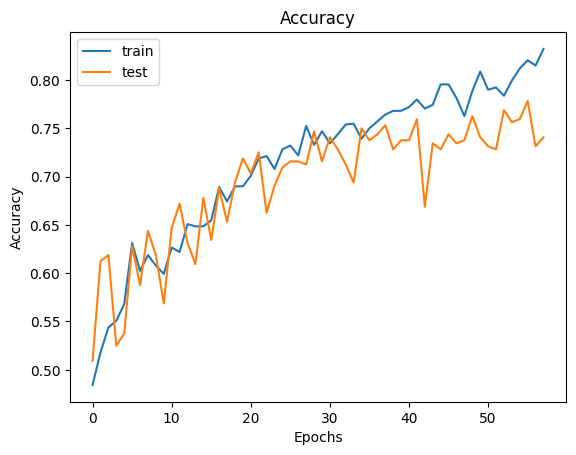

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend(['train','test'],loc='upper left')
plt.show()

# Loss Visulization

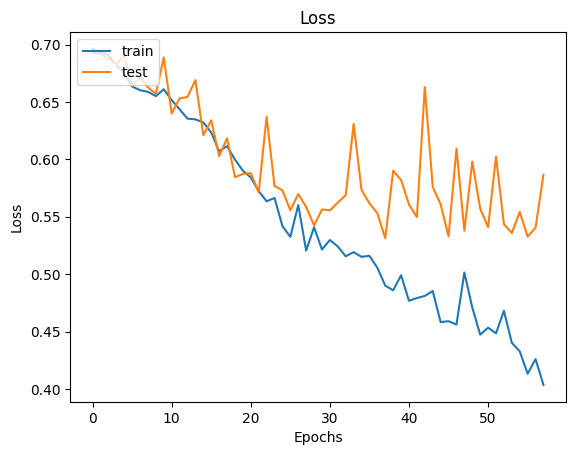

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend(['train','test'],loc='upper left')
plt.show()

# Model Score

In [24]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])

Final Training Accuracy: 0.83203125
Final Validation Accuracy: 0.7406250238418579


# Prediction

In [26]:
pred_img = load_img('test-dog2.webp',target_size=(224,224))
img_array = np.array(pred_img)/255.0
img_array = np.expand_dims(img_array,axis=0)
pred = model.predict(img_array)
if pred[0][0] > (0.5):
  print("Dog")
else:
  print("Cat")

FileNotFoundError: [Errno 2] No such file or directory: 'test-dog2.webp'